In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from nnsight import LanguageModel

model = LanguageModel("Qwen/Qwen3-B")

tokenizer = model.tokenizer

In [3]:
import numpy as np
from tqdm import trange

article_first = [
    ['An artist Jane paints', 'The artist Jane paints'],
    ['The pet fish swims', 'A pet fish swims'],
    ['An animal fish swims', 'The animal fish swims'],
    ['A friend Tom visits', 'The friend Tom visits'],
    ['The woman Mary cooks', 'A woman Mary cooks'],
    ['A machine needs fuel', 'The machine needs fuel'],
    ['A toy is fun', 'The toy is fun'],
    ['A plant loves sun', 'The plant loves sun'],
    ['The dog is loud', 'A dog is loud'],
    ['A breeze blows softly', 'The breeze blows softly'],
    ['The mouse runs away', 'A mouse runs away'],
    ['A child plays happily', 'The child plays happily'],
    ['A clock ticks slowly', 'The clock ticks slowly'],
    ['A book smells fresh', 'The book smells fresh'],
    ['The library is peaceful', 'A library is peaceful'],
    ['A street sounds noisy', 'The street sounds noisy'],
    ['The train arrives soon', 'A train arrives soon'],
    ['A knife cuts easily', 'The knife cuts easily'],
    ['A flower smells sweet', 'The flower smells sweet'],
    ['A wire bends easily', 'The wire bends easily'],
]


PROMPT_TEMPLATE = """A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza
{}. Q: What is the first word in the previous sentence? A:"""

# Prepare all prompts and target tokens
clean_sentences = [pair[0] for pair in article_first]
corrupt_sentences = [pair[1] for pair in article_first]

clean_prompts = [PROMPT_TEMPLATE.format(sent) for sent in clean_sentences]
corrupt_prompts = [PROMPT_TEMPLATE.format(sent) for sent in corrupt_sentences]

# Extract target tokens (first word of each sentence, which is the article)
clean_targets = [model.tokenizer.encode(sent.split()[0], add_special_tokens=False)[0] 
                 for sent in clean_sentences]
corrupt_targets = [model.tokenizer.encode(sent.split()[0], add_special_tokens=False)[0] 
                   for sent in corrupt_sentences]

# Get token length (should be same for all)
n_tokens = len(model.tokenizer.encode(clean_prompts[0]))
print(f"Number of tokens per prompt: {n_tokens}")


Number of tokens per prompt: 61


In [4]:
# STEP 1: Batch clean run - get activations for all 20 prompts
clean_activations = []
clean_logit_diffs = []

with model.trace(clean_prompts):
    # Get activations from all layers
    for l in range(model.config.num_hidden_layers):
        residual_output = model.model.layers[l].output[0].save()
        clean_activations.append(residual_output)
    
    # Get logit differences for all prompts
    logits = model.output.logits
    for i in range(len(clean_prompts)):
        clean_logit_diff = (
            logits[i, -1, clean_targets[i]] - logits[i, -1, corrupt_targets[i]]
        ).save()
        clean_logit_diffs.append(clean_logit_diff)

Loading checkpoint shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [5]:
# STEP 2: Batch corrupt run - get baseline logit diffs
corrupt_logit_diffs = []

with model.trace(corrupt_prompts):
    logits = model.output.logits
    for i in range(len(corrupt_prompts)):
        corrupt_logit_diff = (
            logits[i, -1, clean_targets[i]] - logits[i, -1, corrupt_targets[i]]
        ).save()
        corrupt_logit_diffs.append(corrupt_logit_diff)

# Calculate total logit diff for each prompt
total_logit_diffs = [clean - corrupt for clean, corrupt in zip(clean_logit_diffs, corrupt_logit_diffs)]
print(f"Baseline logit differences shape: {len(total_logit_diffs)}")

Baseline logit differences shape: 20


In [6]:
# STEP 3: Activation Patching - iterate through layers and tokens
# We'll accumulate normalized scores across all prompts
accumulated_scores = []

for l in trange(model.config.num_hidden_layers, desc="Layers"):
    layer_scores = []
    
    for t in range(n_tokens):
        # Batch all 20 prompts for this specific (layer, token) patch
        
        # Calculate normalized scores for each prompt
        normalized_scores = []
        with model.trace(corrupt_prompts):
            # Patch the activation for all prompts at once
            for i in range(len(corrupt_prompts)):
                model.model.layers[l].output[0][i, t, :] = clean_activations[l][i, t, :]
            
            # Get patched logits for all prompts
            patched_logits = model.output.logits
            
            for i in range(len(corrupt_prompts)):
                patched_logit_diff = (
                    patched_logits[i, -1, clean_targets[i]] - patched_logits[i, -1, corrupt_targets[i]]
                )
                
                # Normalize
                if total_logit_diffs[i] == 0:
                    normalized_score = 0.0
                else:
                    normalized_score = (patched_logit_diff - corrupt_logit_diffs[i]) / total_logit_diffs[i]
                
                normalized_scores.append(normalized_score.save())
        
        # Average across all 20 prompts for this (layer, token) position
        avg_score = sum([score.item() for score in normalized_scores]) / len(normalized_scores)
        layer_scores.append(avg_score)
        print(f"L{l}, T{t}, Avg_LD={avg_score:.4f}")
    
    accumulated_scores.append(layer_scores)

print(f"\nAccumulated scores shape: {len(accumulated_scores)} layers x {len(accumulated_scores[0])} tokens")

Layers:   0%|          | 0/64 [00:00<?, ?it/s]

L0, T0, Avg_LD=0.0000


Layers:   0%|          | 0/64 [01:13<?, ?it/s]


KeyboardInterrupt: 

In [7]:
FEW_SHOT_EXAMPLES = """A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza\n"""
FSE_TOKENS = [tok.replace("Ġ", " ").replace("Ċ", "\n") for tok in model.tokenizer.tokenize(FEW_SHOT_EXAMPLES)]

In [ ]:
QUESTION = "Q: What is the first word in the previous sentence?"
QUESTION_TOKENS = [tok.replace("Ġ", " ").replace("Ċ", "\n") for tok in model.tokenizer.tokenize(QUESTION)]

Data range: min=-0.0202, max=1.0127


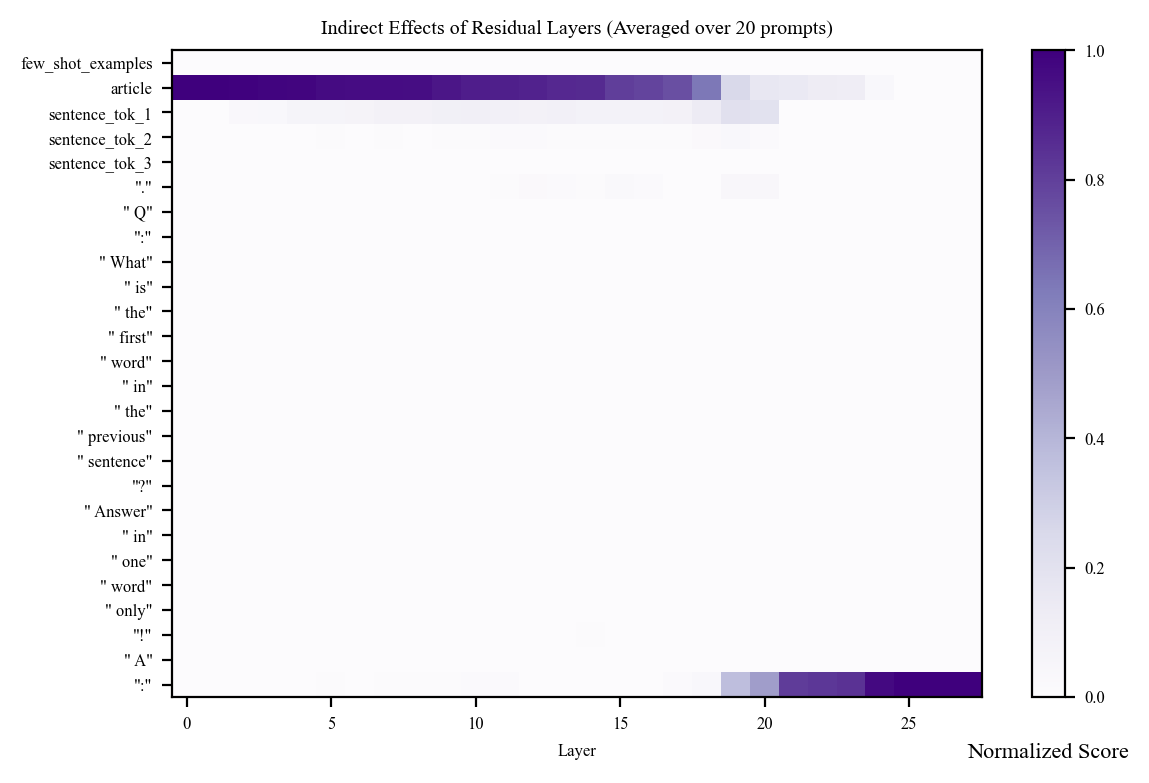

In [9]:
# Visualization code (mostly unchanged from your original)
import matplotlib.pyplot as plt
import numpy as np

# Use the accumulated scores
scores = np.array(accumulated_scores).T  # Transpose so tokens are rows, layers are columns

# Decode tokens from the first clean prompt (they're all the same structure)
clean_input_ids = model.tokenizer.encode(clean_prompts[0])
clean_tokens = [model.tokenizer.decode([token_id]) for token_id in clean_input_ids]

# Create token labels
tokens = ["few_shot_examples", "article", "sentence_tok_1", "sentence_tok_2", "sentence_tok_3",]
for idx, clean_tok in enumerate(clean_tokens):
    if idx < (len(FSE_TOKENS) + 4):
        continue
    tokens.append(f'"{clean_tok}"')

# Aggregate few-shot tokens
num_fse_tokens = len(FSE_TOKENS)
fse_aggregated = scores[:num_fse_tokens].mean(axis=0, keepdims=True)
remaining_scores = scores[num_fse_tokens:]
collapsed_scores = np.vstack([fse_aggregated, remaining_scores])

print(f"Data range: min={collapsed_scores.min():.4f}, max={collapsed_scores.max():.4f}")

# Plot
plt.rcdefaults()
with plt.rc_context(rc={"font.family": "Times New Roman", "font.size": 6}):
    fig, ax = plt.subplots(figsize=(6, len(tokens) * 0.08 + 1.8), dpi=200)
    
    heatmap = ax.pcolor(collapsed_scores, cmap="Purples", vmin=0, vmax=1)
    ax.invert_yaxis()
    
    # Y-axis: token labels
    ax.set_yticks([0.5 + i for i in range(len(tokens))])
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels
    num_layers = collapsed_scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)
    ax.set_xticklabels(tick_indices)
    
    ax.set_title("Indirect Effects of Residual Layers (Averaged over 20 prompts)")
    ax.set_xlabel("Layer")
    
    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title("Normalized Score", y=-0.12, fontsize=8)
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('indirect_effects_heatmap_article_first.png', dpi=300, bbox_inches='tight')
    
    plt.show()  # Optional: remove if you don't want to display it